In [1]:
!pip install timm torch torchvision matplotlib

In [1]:
# Import libraries
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = "2"  # 0=all logs, 1=filter INFO, 2=filter WARNING, 3=filter ERROR
import numpy as np
import pandas as pd
import cv2
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import timm

/home/mahabur-alam/anaconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parameters
DATA_PATH = "../Data/Scores"
BATCH_SIZE = 32
EPOCHS = 20 
IMG_SIZE = 224
LR = 0.0001
DEVICE = torch.device("cpu")  # Force CPU

In [13]:
# Transforms (resize + normalize for ViT)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

In [14]:
# Load dataset
train_dataset = datasets.ImageFolder(DATA_PATH, transform=train_transform)
class_names = train_dataset.classes

print(f"Dataset loaded: {len(train_dataset)} samples, {len(class_names)} classes")
print(f"[INFO] Classes: {class_names}")

Classes: ['Circle', 'Diagonal', 'Overlapped circle', 'Overlapped pencils', 'Square', 'Star', 'Triangle', 'Wave']


In [15]:
# Split train/test
train_size = int(0.8 * len(train_dataset))
test_size = len(train_dataset) - train_size
train_data, test_data = torch.utils.data.random_split(train_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"[INFO] Train: ({len(train_data)}")
print(f"[INFO] Test: ({len(test_data)}")

In [16]:
# Define Vision Transformer Model
model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=len(class_names))
model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [17]:
# Training Loop
train_losses, test_losses, train_acc, test_acc = [], [], [], []

for epoch in range(EPOCHS):
    model.train()
    correct, total, running_loss = 0, 0, 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    train_losses.append(train_loss)
    train_acc.append(train_accuracy)
    
    # Validation
    model.eval()
    correct, total, val_loss = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss = val_loss / len(test_loader)
    test_accuracy = 100 * correct / total
    test_losses.append(test_loss)
    test_acc.append(test_accuracy)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}% | "
          f"Val Loss: {test_loss:.4f}, Val Acc: {test_accuracy:.4f}%")

Epoch [1/20] Train Loss: 0.2142, Train Acc: 94.9098% | Val Loss: 0.0634, Val Acc: 98.8372%
Epoch [2/20] Train Loss: 0.0864, Train Acc: 98.3421% | Val Loss: 0.1038, Val Acc: 98.2558%
Epoch [3/20] Train Loss: 0.0937, Train Acc: 98.1966% | Val Loss: 0.0873, Val Acc: 98.1395%
Epoch [4/20] Train Loss: 0.0825, Train Acc: 98.4293% | Val Loss: 0.0693, Val Acc: 98.8372%
Epoch [5/20] Train Loss: 0.0825, Train Acc: 98.3421% | Val Loss: 0.6790, Val Acc: 88.9535%
Epoch [6/20] Train Loss: 0.0839, Train Acc: 98.3130% | Val Loss: 0.0954, Val Acc: 97.7907%
Epoch [7/20] Train Loss: 0.0623, Train Acc: 98.6038% | Val Loss: 0.0683, Val Acc: 98.6047%
Epoch [8/20] Train Loss: 0.0762, Train Acc: 98.3421% | Val Loss: 0.0803, Val Acc: 98.6047%
Epoch [9/20] Train Loss: 0.0547, Train Acc: 98.7784% | Val Loss: 0.0603, Val Acc: 98.6047%
Epoch [10/20] Train Loss: 0.0452, Train Acc: 98.9529% | Val Loss: 0.0736, Val Acc: 98.9535%
Epoch [11/20] Train Loss: 0.0346, Train Acc: 99.0692% | Val Loss: 0.1073, Val Acc: 98.604

In [21]:
# Evaluate ViT
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:  # test_loader is your DataLoader
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())


# Accuracy
acc_vit = accuracy_score(y_true, y_pred)
print(f"[RESULT] ViT Test Accuracy: {acc_vit:.4f}")

[RESULT] ViT Test Accuracy: 0.9779


In [28]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("[INFO] Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("[INFO] Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

[INFO] Classification Report:
                    precision    recall  f1-score   support

            Circle       1.00      0.99      1.00       121
          Diagonal       0.95      0.99      0.97       106
 Overlapped circle       0.98      0.99      0.99       117
Overlapped pencils       0.98      1.00      0.99        98
            Square       0.99      1.00      1.00       122
              Star       1.00      0.99      0.99        88
          Triangle       1.00      0.90      0.95       105
              Wave       0.97      1.00      0.99       103

          accuracy                           0.98       860
         macro avg       0.98      0.98      0.98       860
      weighted avg       0.98      0.98      0.98       860

[INFO] Confusion Matrix:
[[120   0   1   0   0   0   0   0]
 [  0 105   1   0   0   0   0   0]
 [  0   0 116   1   0   0   0   0]
 [  0   0   0  98   0   0   0   0]
 [  0   0   0   0 122   0   0   0]
 [  0   0   0   1   0  87   0   0]
 [  0   6   

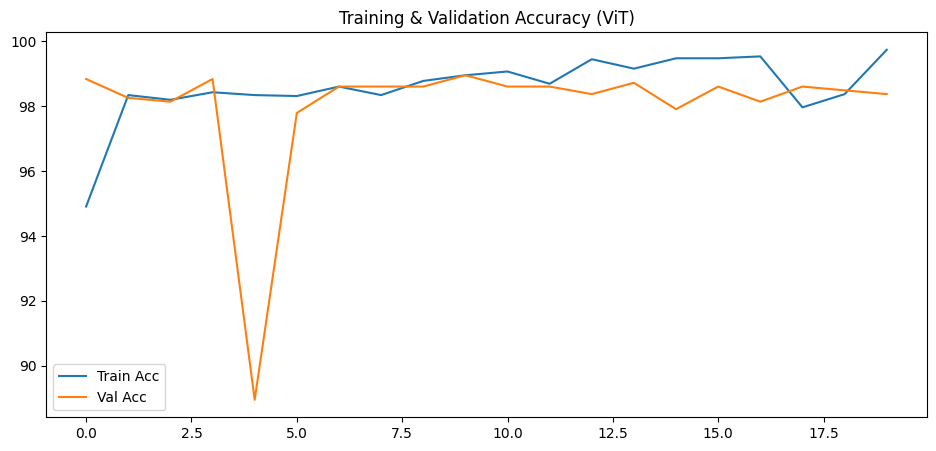

In [33]:
# Plot Accuracy & Loss
plt.figure(figsize=(25,5))
plt.subplot(1,2,2)
plt.plot(train_acc, label="Train Acc")
plt.plot(test_acc, label="Val Acc")
plt.legend(); plt.title("Training & Validation Accuracy (ViT)")
plt.show()

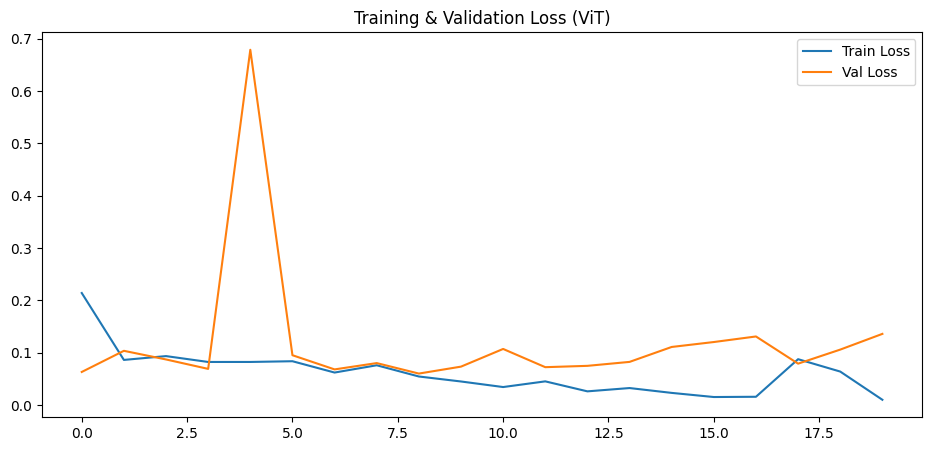

In [35]:
# Plot Loss & Accuracy
plt.figure(figsize=(25,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Val Loss")
plt.legend(); plt.title("Training & Validation Loss (ViT)")
plt.show()

In [36]:
# Save Model
SAVE_DIR = "./model_outputs/visionTransformer"
os.makedirs(SAVE_DIR, exist_ok=True)

In [38]:
# Accuracy Plot
plt.figure(figsize=(10, 5))
plt.plot(train_acc, label="Train Acc")
plt.plot(test_acc, label="Val Acc")
plt.legend(); plt.title("Training & Validation Accuracy (ViT)")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_plot.png"))
plt.close()

In [39]:
# Save Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Val Loss")
plt.legend(); plt.title("Training & Validation Loss (ViT)")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_plot.png"))
plt.close()

In [42]:
# Save trained model
MODEL_PATH = os.path.join(SAVE_DIR, "ViT_model.h5")
torch.save(model.state_dict(), MODEL_PATH)
# print(f"[INFO] Model saved successfully at: {MODEL_PATH}")
print("[INFO] Model saved successfully")

[INFO] Model saved successfully


In [43]:
# Combine history into a DataFrame
history_df = pd.DataFrame({
    "epoch": list(range(1, EPOCHS + 1)),
    "train_loss": train_losses,
    "val_loss": test_losses,
    "train_accuracy": train_acc,
    "val_accuracy": test_acc
})

os.makedirs(SAVE_DIR, exist_ok=True)

# Save to CSV
history_path = os.path.join(SAVE_DIR, "ViT_training_history.csv")
history_df.to_csv(history_path, index=False)

print(f"[INFO] Training history saved successfully at: {history_path}")

[INFO] Training history saved successfully at: ./model_outputs/visionTransformer/ViT_training_history.csv


In [45]:
# Save classification report
report_df = pd.DataFrame(report_dict).transpose()

report_path = os.path.join(SAVE_DIR, "classification_report.csv")
report_df.to_csv(report_path, index=True)

print(f"[INFO] Classification report saved successfully at: {report_path}")

[INFO] Classification report saved successfully at: ./model_outputs/visionTransformer/classification_report.csv


In [ ]:
# Step 9: Test a few images
def imshow(img, title):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.title(title)
    plt.show()

dataiter = iter(test_loader)
images, labels = next(dataiter)
outputs = model(images.to(DEVICE))
_, preds = torch.max(outputs, 1)

for i in range(min(5, len(images))):
    imshow(images[i], f"Pred: {class_names[preds[i]]}, True: {class_names[labels[i]]}")